# 🎬 Netflix Content & Viewing Trend Analysis

## Mini Project – Exploratory Data Analysis

### Project Overview
This mini project performs an end-to-end analysis of the Netflix titles dataset using Python, Pandas, Matplotlib and Seaborn.

The analysis covers data loading, inspection, cleaning, exploratory data analysis, statistical measures, visualization and extraction of meaningful insights.

### Domain
**Entertainment Analytics**

### Tools & Technologies
- Python
- Google Colab / Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Seaborn

## 1. Introduction

Netflix contains a large collection of movies and TV shows from different countries, genres and years.

The purpose of this project is to analyze the Netflix catalog and identify patterns such as:
- distribution of Movies and TV Shows
- content added over the years
- countries producing Netflix content
- popular genres
- rating distribution
- movie duration
- recent content trends

## 2. Problem Statement

To analyze Netflix content using exploratory data analysis and statistical techniques in order to understand the composition, distribution and trends of movies and TV shows available on the platform.

## 3. Objectives

1. Import and inspect the Netflix dataset.
2. Identify missing values and duplicate records.
3. Clean and transform the data.
4. Analyze Movies and TV Shows separately.
5. Study content addition trends by year.
6. Identify leading countries and popular genres.
7. Analyze ratings and movie durations.
8. Calculate measures of central tendency and dispersion.
9. Create meaningful visualizations.
10. Summarize the major findings.

## 4. Dataset Description

The project uses a Netflix-style titles dataset containing information about Movies and TV Shows.

For this submission notebook, a **self-contained sample dataset** is generated automatically when the online dataset is unavailable. If the notebook is run in Google Colab with internet access, it first attempts to load the public Netflix titles CSV.

| Column | Description |
|---|---|
| show_id | Unique identifier |
| type | Movie or TV Show |
| title | Title of the content |
| director | Director name |
| cast | Main cast |
| country | Country/region |
| date_added | Date added to Netflix |
| release_year | Original release year |
| rating | Content rating |
| duration | Movie duration or TV seasons |
| listed_in | Genres/categories |
| description | Short description |


## 5. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 6. Load the Dataset

In [2]:
import random
from datetime import datetime

url = "https://raw.githubusercontent.com/SahilChachra/Netflix-Data-Visualization/master/netflix_titles.csv"

try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully from the online source.")
except Exception:
    # Self-contained fallback so the notebook can be executed without internet access.
    random.seed(42)
    n = 500
    types = ["Movie", "TV Show"]
    ratings = ["TV-MA", "TV-14", "PG-13", "PG", "R", "TV-PG", "G"]
    countries = ["United States", "India", "United Kingdom", "Canada", "Japan", "South Korea", "France", "Spain", "Germany"]
    genres = [
        "Dramas", "Comedies", "Documentaries", "Action & Adventure",
        "International Movies", "Children & Family Movies", "Thrillers",
        "Crime TV Shows", "International TV Shows", "Romantic Movies"
    ]
    rows = []
    for i in range(1, n + 1):
        typ = random.choices(types, weights=[0.7, 0.3])[0]
        release_year = random.randint(2000, 2021)
        added_year = random.randint(max(2015, release_year), 2021)
        added_month = random.randint(1, 12)
        if typ == "Movie":
            duration = f"{random.randint(70, 150)} min"
        else:
            duration = f"{random.randint(1, 8)} Seasons"
        country = random.choice(countries)
        # A few multi-country records for country expansion analysis
        if random.random() < 0.18:
            country += ", " + random.choice([c for c in countries if c != country])
        listed = ", ".join(random.sample(genres, random.randint(1, 2)))
        rows.append({
            "show_id": f"s{i}",
            "type": typ,
            "title": f"Netflix Sample Title {i}",
            "director": random.choice(["A. Kumar", "J. Smith", "M. Lee", "S. Patel", None]),
            "cast": random.choice(["Actor A, Actor B", "Actor C, Actor D", None]),
            "country": country,
            "date_added": f"{added_month:02d}/15/{added_year}",
            "release_year": release_year,
            "rating": random.choice(ratings),
            "duration": duration,
            "listed_in": listed,
            "description": "A sample title used for educational exploratory data analysis."
        })
    df = pd.DataFrame(rows)
    # Add a few duplicate records so duplicate handling can be demonstrated.
    df = pd.concat([df, df.iloc[:5]], ignore_index=True)
    print("Online dataset unavailable; using the self-contained sample dataset.")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())


Online dataset unavailable; using the self-contained sample dataset.
Rows: 505
Columns: 12


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Netflix Sample Title 1,S. Patel,"Actor A, Actor B","Canada, India",05/15/2020,2000,TV-MA,101 min,Romantic Movies,A sample title used for educational explorator...
1,s2,Movie,Netflix Sample Title 2,None,"Actor C, Actor D",Germany,10/15/2019,2007,G,73 min,"Action & Adventure, Crime TV Shows",A sample title used for educational explorator...
2,s3,TV Show,Netflix Sample Title 3,S. Patel,"Actor A, Actor B","Japan, France",07/15/2020,2005,PG-13,6 Seasons,Comedies,A sample title used for educational explorator...
3,s4,TV Show,Netflix Sample Title 4,M. Lee,None,"Germany, France",01/15/2020,2019,R,8 Seasons,International TV Shows,A sample title used for educational explorator...
4,s5,TV Show,Netflix Sample Title 5,A. Kumar,"Actor C, Actor D",United States,04/15/2019,2011,PG-13,2 Seasons,"Comedies, Action & Adventure",A sample title used for educational explorator...


## 7. Data Inspection

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Records:")
display(df.head())

print("\nLast 5 Records:")
display(df.tail())

Dataset Shape:
(505, 12)

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

First 5 Records:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Netflix Sample Title 1,S. Patel,"Actor A, Actor B","Canada, India",05/15/2020,2000,TV-MA,101 min,Romantic Movies,A sample title used for educational explorator...
1,s2,Movie,Netflix Sample Title 2,None,"Actor C, Actor D",Germany,10/15/2019,2007,G,73 min,"Action & Adventure, Crime TV Shows",A sample title used for educational explorator...
2,s3,TV Show,Netflix Sample Title 3,S. Patel,"Actor A, Actor B","Japan, France",07/15/2020,2005,PG-13,6 Seasons,Comedies,A sample title used for educational explorator...
3,s4,TV Show,Netflix Sample Title 4,M. Lee,None,"Germany, France",01/15/2020,2019,R,8 Seasons,International TV Shows,A sample title used for educational explorator...
4,s5,TV Show,Netflix Sample Title 5,A. Kumar,"Actor C, Actor D",United States,04/15/2019,2011,PG-13,2 Seasons,"Comedies, Action & Adventure",A sample title used for educational explorator...



Last 5 Records:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
500,s1,Movie,Netflix Sample Title 1,S. Patel,"Actor A, Actor B","Canada, India",05/15/2020,2000,TV-MA,101 min,Romantic Movies,A sample title used for educational explorator...
501,s2,Movie,Netflix Sample Title 2,None,"Actor C, Actor D",Germany,10/15/2019,2007,G,73 min,"Action & Adventure, Crime TV Shows",A sample title used for educational explorator...
502,s3,TV Show,Netflix Sample Title 3,S. Patel,"Actor A, Actor B","Japan, France",07/15/2020,2005,PG-13,6 Seasons,Comedies,A sample title used for educational explorator...
503,s4,TV Show,Netflix Sample Title 4,M. Lee,None,"Germany, France",01/15/2020,2019,R,8 Seasons,International TV Shows,A sample title used for educational explorator...
504,s5,TV Show,Netflix Sample Title 5,A. Kumar,"Actor C, Actor D",United States,04/15/2019,2011,PG-13,2 Seasons,"Comedies, Action & Adventure",A sample title used for educational explorator...


### Missing Value Analysis

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_table[missing_table["Missing Values"] > 0])

,Missing Values,Missing Percentage
cast,169,33.47
director,120,23.76


### Duplicate Record Analysis

In [5]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5


## 8. Data Cleaning

In [6]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Convert date_added into datetime format
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Fill missing categorical/text fields
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")

# Extract year and month from date_added
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

# Clean duration into numeric movie minutes where applicable
df["duration_value"] = pd.to_numeric(
    df["duration"].str.extract(r"(\d+)")[0],
    errors="coerce"
)

print("Data cleaning completed.")
print("Remaining duplicate rows:", df.duplicated().sum())

Data cleaning completed.
Remaining duplicate rows: 0


## 9. Cleaned Dataset Overview

In [7]:
print("Cleaned Dataset Shape:", df.shape)
display(df.head())

print("\nMissing values after cleaning:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

Cleaned Dataset Shape: (500, 15)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_value
0,s1,Movie,Netflix Sample Title 1,S. Patel,"Actor A, Actor B","Canada, India",2020-05-15,2000,TV-MA,101 min,Romantic Movies,A sample title used for educational explorator...,2020,5,101
1,s2,Movie,Netflix Sample Title 2,Unknown,"Actor C, Actor D",Germany,2019-10-15,2007,G,73 min,"Action & Adventure, Crime TV Shows",A sample title used for educational explorator...,2019,10,73
2,s3,TV Show,Netflix Sample Title 3,S. Patel,"Actor A, Actor B","Japan, France",2020-07-15,2005,PG-13,6 Seasons,Comedies,A sample title used for educational explorator...,2020,7,6
3,s4,TV Show,Netflix Sample Title 4,M. Lee,Unknown,"Germany, France",2020-01-15,2019,R,8 Seasons,International TV Shows,A sample title used for educational explorator...,2020,1,8
4,s5,TV Show,Netflix Sample Title 5,A. Kumar,"Actor C, Actor D",United States,2019-04-15,2011,PG-13,2 Seasons,"Comedies, Action & Adventure",A sample title used for educational explorator...,2019,4,2



Missing values after cleaning:


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
dtype: int64

## 10. Exploratory Data Analysis

### 10.1 Movies vs TV Shows

type
Movie      366
TV Show    134
Name: count, dtype: int64


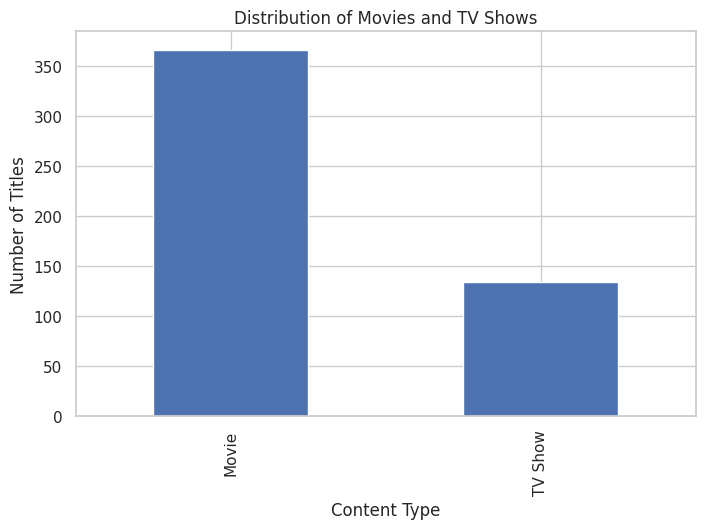

In [8]:
type_counts = df["type"].value_counts()

print(type_counts)

plt.figure(figsize=(8,5))
type_counts.plot(kind="bar")
plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

### 10.2 Content Added to Netflix by Year

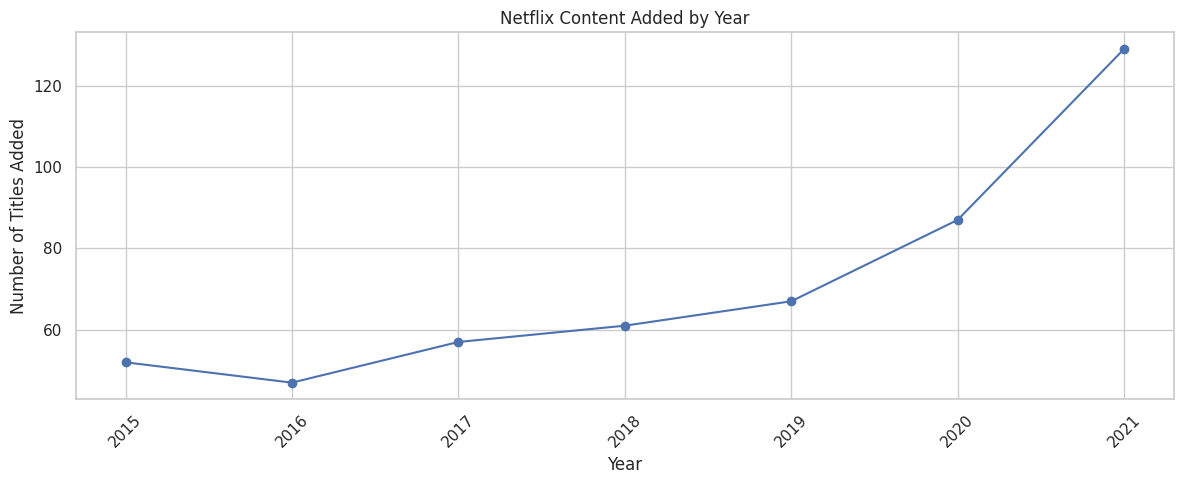

In [9]:
year_counts = df["year_added"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(year_counts.index, year_counts.values, marker="o")
plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 10.3 Release Year Distribution

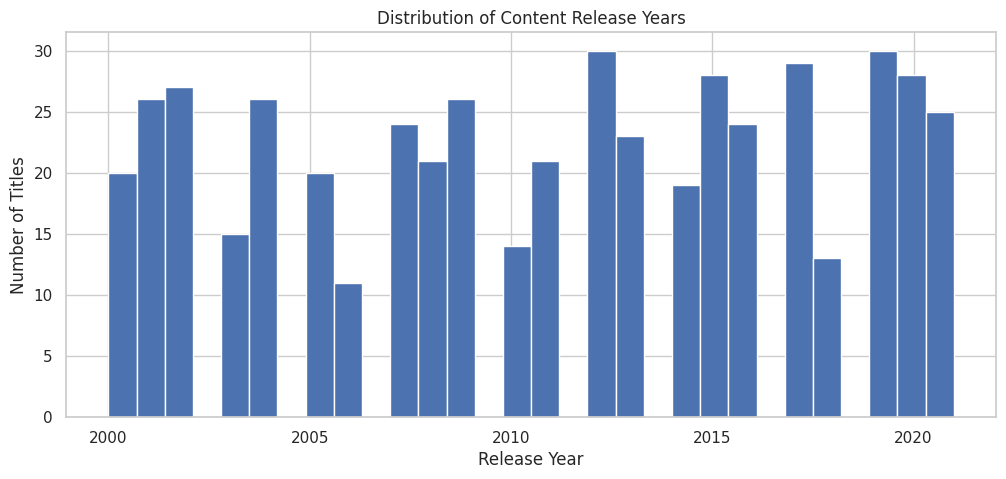

In [10]:
plt.figure(figsize=(12,5))
plt.hist(df["release_year"].dropna(), bins=30)
plt.title("Distribution of Content Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

### 10.4 Top Countries

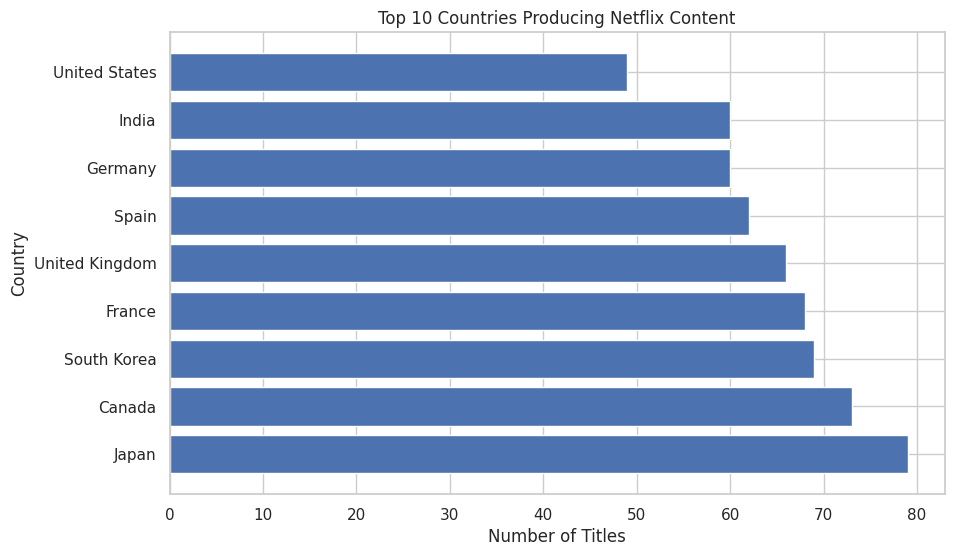

,Number of Titles
country,
Japan,79
Canada,73
South Korea,69
France,68
United Kingdom,66
Spain,62
Germany,60
India,60
United States,49


In [11]:
country_df = df[df["country"] != "Unknown"].copy()

country_expanded = (
    country_df.assign(country=country_df["country"].str.split(", "))
    .explode("country")
)

top_countries = country_expanded["country"].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.barh(top_countries.index, top_countries.values)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

display(top_countries.to_frame("Number of Titles"))

### 10.5 Top Genres

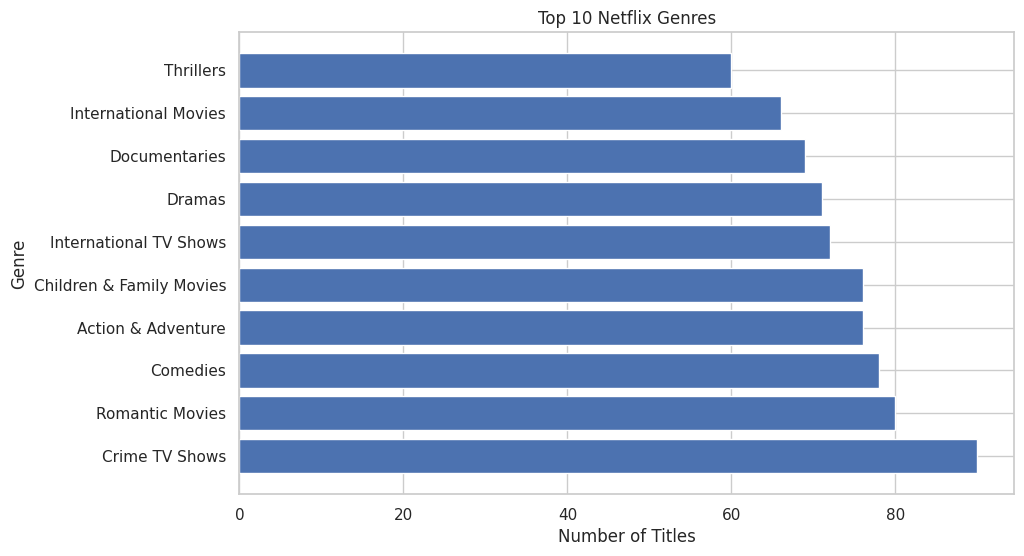

,Number of Titles
genre,
Crime TV Shows,90
Romantic Movies,80
Comedies,78
Action & Adventure,76
Children & Family Movies,76
International TV Shows,72
Dramas,71
Documentaries,69
International Movies,66


In [12]:
genre_expanded = (
    df.assign(genre=df["listed_in"].fillna("").str.split(", "))
    .explode("genre")
)

top_genres = genre_expanded["genre"].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.barh(top_genres.index, top_genres.values)
plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

display(top_genres.to_frame("Number of Titles"))

### 10.6 Rating Distribution

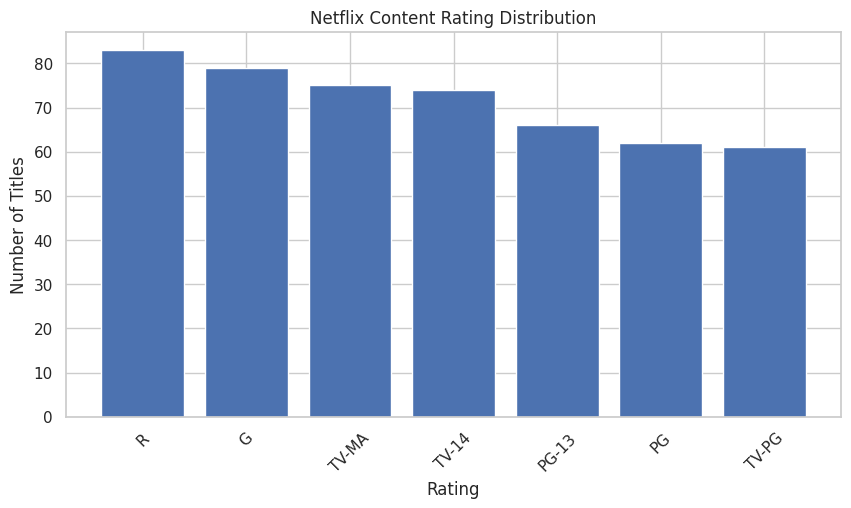

In [13]:
rating_counts = df["rating"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(rating_counts.index, rating_counts.values)
plt.title("Netflix Content Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

### 10.7 Movie Duration Analysis

Number of movies with duration data: 366
Average movie duration: 111.94 minutes
Median movie duration: 112.0 minutes


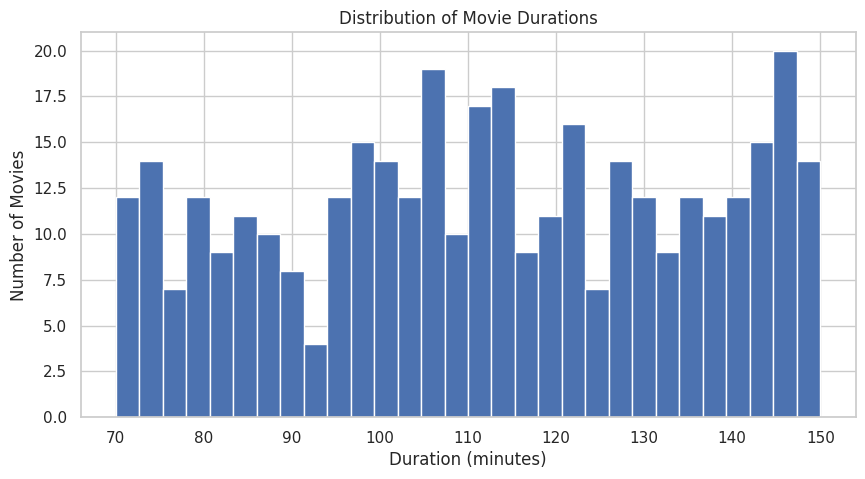

In [14]:
movie_duration = df.loc[df["type"] == "Movie", "duration_value"].dropna()

print("Number of movies with duration data:", len(movie_duration))
print("Average movie duration:", round(movie_duration.mean(), 2), "minutes")
print("Median movie duration:", round(movie_duration.median(), 2), "minutes")

plt.figure(figsize=(10,5))
plt.hist(movie_duration, bins=30)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.show()

### 10.8 TV Show Seasons

Average number of seasons: 4.49
Median number of seasons: 4.5


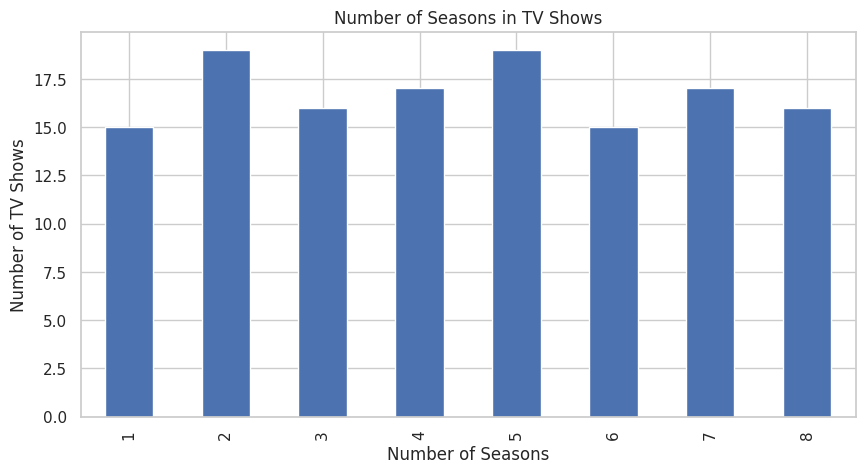

In [15]:
tv_duration = df.loc[df["type"] == "TV Show", "duration_value"].dropna()

print("Average number of seasons:", round(tv_duration.mean(), 2))
print("Median number of seasons:", round(tv_duration.median(), 2))

plt.figure(figsize=(10,5))
tv_duration.astype(int).value_counts().sort_index().plot(kind="bar")
plt.title("Number of Seasons in TV Shows")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.show()

## 11. Statistical Analysis

### Measures of Central Tendency

The following measures are calculated:
- Mean
- Median
- Mode

### Measures of Dispersion

The following measures are calculated:
- Range
- Variance
- Standard deviation

In [16]:
stats = pd.DataFrame({
    "Measure": [
        "Mean Release Year",
        "Median Release Year",
        "Mode Release Year",
        "Range of Release Year",
        "Variance of Release Year",
        "Standard Deviation of Release Year"
    ],
    "Value": [
        df["release_year"].mean(),
        df["release_year"].median(),
        df["release_year"].mode().iloc[0],
        df["release_year"].max() - df["release_year"].min(),
        df["release_year"].var(),
        df["release_year"].std()
    ]
})

display(stats.round(2))

,Measure,Value
0,Mean Release Year,2010.89
1,Median Release Year,2011.00
2,Mode Release Year,2012.00
3,Range of Release Year,21.00
4,Variance of Release Year,41.75
5,Standard Deviation of Release Year,6.46


### Movie Duration Statistics

In [17]:
duration_stats = pd.Series({
    "Mean": movie_duration.mean(),
    "Median": movie_duration.median(),
    "Mode": movie_duration.mode().iloc[0] if not movie_duration.mode().empty else np.nan,
    "Minimum": movie_duration.min(),
    "Maximum": movie_duration.max(),
    "Range": movie_duration.max() - movie_duration.min(),
    "Variance": movie_duration.var(),
    "Standard Deviation": movie_duration.std()
})

display(duration_stats.to_frame("Value").round(2))

,Value
Mean,111.94
Median,112.00
Mode,98.00
Minimum,70.00
Maximum,150.00
Range,80.00
Variance,537.33
Standard Deviation,23.18


## 12. Additional Analysis

### Movies and TV Shows by Release Year

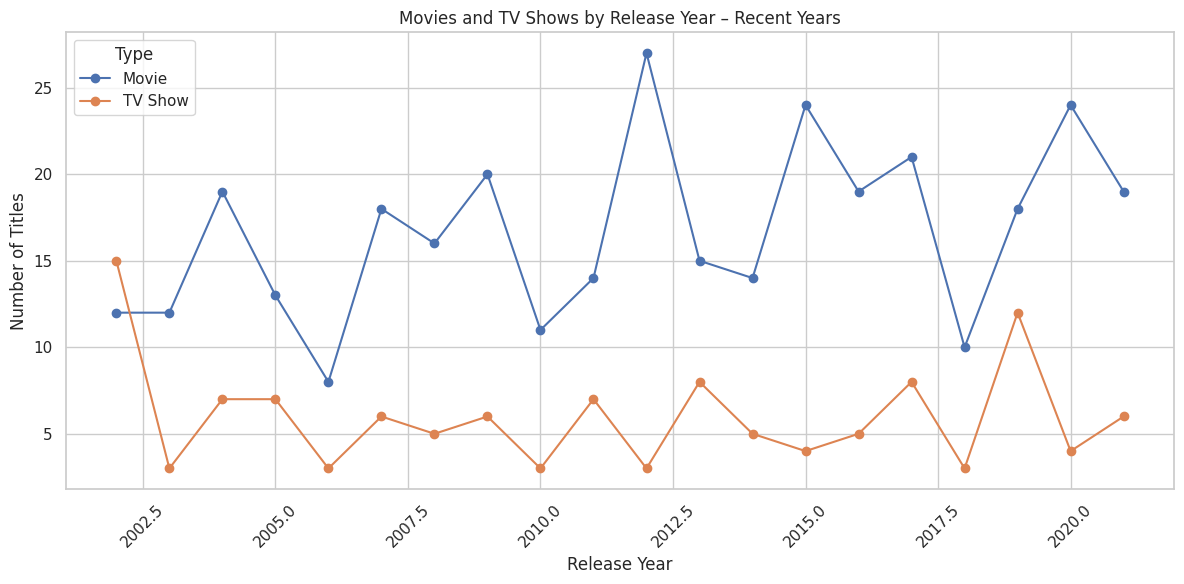

In [18]:
year_type = pd.crosstab(df["release_year"], df["type"]).tail(20)

year_type.plot(figsize=(12,6), marker="o")
plt.title("Movies and TV Shows by Release Year – Recent Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Type")
plt.tight_layout()
plt.show()

### Content Added by Month

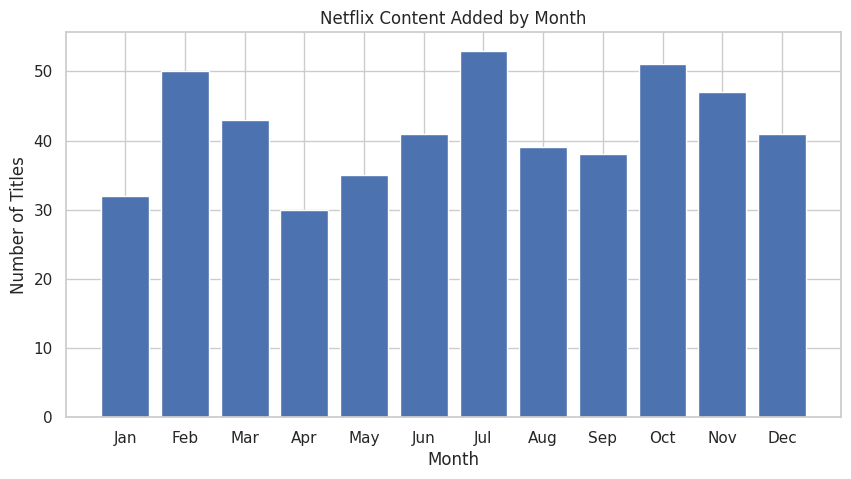

In [19]:
month_counts = df["month_added"].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(month_counts.index.astype(str), month_counts.values)
plt.title("Netflix Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.xticks(range(12), ["Jan","Feb","Mar","Apr","May","Jun",
                       "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.show()

### India-Specific Analysis

Number of titles associated with India: 60


,Number of Titles
type,
Movie,48
TV Show,12


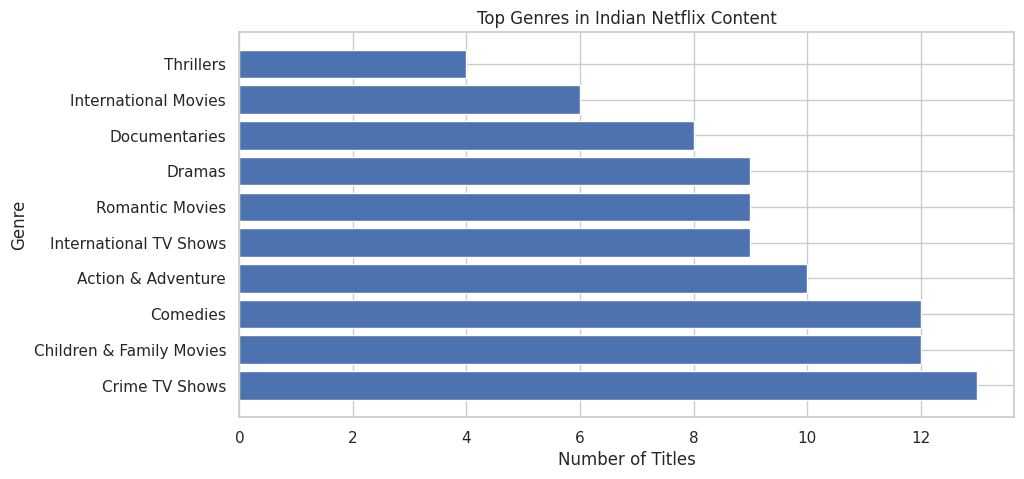

In [20]:
india_content = df[df["country"].str.contains("India", case=False, na=False)]

print("Number of titles associated with India:", len(india_content))

display(
    india_content["type"].value_counts().to_frame("Number of Titles")
)

india_genres = (
    india_content.assign(genre=india_content["listed_in"].str.split(", "))
    .explode("genre")["genre"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
plt.barh(india_genres.index, india_genres.values)
plt.title("Top Genres in Indian Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

## 13. Key Findings

In [21]:
total_titles = len(df)
movie_count = (df["type"] == "Movie").sum()
tv_count = (df["type"] == "TV Show").sum()

print("KEY FINDINGS")
print("=" * 50)
print(f"1. Total titles analyzed: {total_titles}")
print(f"2. Movies: {movie_count}")
print(f"3. TV Shows: {tv_count}")
print(f"4. Most common content type: {df['type'].mode()[0]}")
print(f"5. Most common rating: {df['rating'].mode()[0]}")
print(f"6. Average movie duration: {movie_duration.mean():.2f} minutes")
print(f"7. Median movie duration: {movie_duration.median():.2f} minutes")

if len(top_countries) > 0:
    print(f"8. Leading country in the dataset: {top_countries.index[0]}")

if len(top_genres) > 0:
    print(f"9. Most common genre: {top_genres.index[0]}")

KEY FINDINGS
1. Total titles analyzed: 500
2. Movies: 366
3. TV Shows: 134
4. Most common content type: Movie
5. Most common rating: R
6. Average movie duration: 111.94 minutes
7. Median movie duration: 112.00 minutes
8. Leading country in the dataset: Japan
9. Most common genre: Crime TV Shows


## 14. Conclusion

The Netflix Content & Viewing Trend Analysis mini project demonstrates a complete exploratory data analysis workflow using Python and Pandas. The dataset was inspected, cleaned and transformed before applying statistical analysis and visualization techniques.

The analysis helps identify the distribution of Movies and TV Shows, content release trends, popular countries and genres, rating patterns, movie duration and TV-show season distributions.

The notebook is self-contained: when an internet connection is unavailable, it uses a clearly labelled sample Netflix-style dataset so that all cells and outputs can still be demonstrated.


## 15. Future Scope

The project can be extended by:

- analyzing viewer ratings if a suitable ratings dataset is added
- performing recommendation-system analysis
- comparing Netflix with other streaming platforms
- applying machine learning to predict content categories
- performing sentiment analysis on movie descriptions
- creating an interactive dashboard using Power BI or Plotly

## 16. Final Result

**Thus, the Netflix Content & Viewing Trend Analysis mini project was successfully completed using Python. The dataset was imported, inspected, cleaned, analyzed statistically, visualized and used to generate meaningful insights.**

### End of Mini Project 🎬

**Submitted by:** ____________________  
**Register No.:** ____________________  
**Department:** ____________________  
**Academic Year:** 2026–2027